In [1]:
# Standard library
import gc
import pickle
import random

# Third-party
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import distributions, nn, optim
import scanpy as sc
import anndata as ad
import squidpy as sq
import umap
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import matplotlib.patheffects as path_effects
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans

# Project / local
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF, batched_Matern32, batched_MGGP_Matern32
from gpzoo.gp import GaussianPrior, SVGP, MGGP_VNNGP, MGGP_WSVGP, VNNGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import (
    whitened_KL,
    train_hybrid,
    train_hybrid_batched,
    anndata_to_train_val,
    rescale_spatial_coords,
    add_jitter,
    scanpy_sizefactors,
    init_softplus,
    regularized_nmf,
    dims_autocorr,
    plot_factors,
    init_Lu,
    init_Lu_nsf
)


/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. I

In [2]:
import os, glob, json
from pathlib import Path

MODELS_DIR = Path("../../models/nsf_benchmarks").resolve()

def _latest_summary_csv(models_dir=MODELS_DIR):
    files = sorted(models_dir.glob("benchmark_summary_*.csv"))
    return files[-1] if files else None

def _load_summary_df():
    csv_path = _latest_summary_csv()
    if csv_path is None:
        print("No benchmark_summary_*.csv found in ../../models/")
        return None
    df = pd.read_csv(csv_path)
    # Add parsed K for easy plotting (SVGP row will have NaN)
    df["K"] = df["label"].str.extract(r"K=(\d+)").astype(float)
    return df

def _model_path_for_full():
    return MODELS_DIR / "toy_nsf.pth"

def _model_path_for_k(K):
    return MODELS_DIR / f"toy_nsf_k={K}.pth"

def _loss_paths_from_weights(weights_path: Path):
    base = weights_path.with_suffix("")  # strip .pth
    return base.with_name(base.name + "_losses.csv"), base.with_name(base.name + "_losses.npy")

def _load_losses(weights_path: Path):
    csv_path, npy_path = _loss_paths_from_weights(weights_path)
    if csv_path.exists():
        losses_df = pd.read_csv(csv_path)
        losses = losses_df["loss"].to_numpy()
    elif npy_path.exists():
        losses = np.load(npy_path)
        losses_df = pd.DataFrame({"step": np.arange(len(losses)), "loss": losses})
    else:
        print(f"No losses file next to {weights_path.name}")
        losses_df = pd.DataFrame({"step": [], "loss": []})
        losses = np.array([])
    return losses, losses_df

def _load_state_dict_safely(model, weights_path: Path, device=torch.device("cpu")):
    state = torch.load(str(weights_path), map_location=device)
    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing or unexpected:
        print(f"Loaded {weights_path.name} with missing={missing} unexpected={unexpected}")
    model.to(device)
    model.eval()
    return model


In [35]:
def plot_factors(
    factors, X,
    moran_idx=None,
    ax=None,
    size=7,
    alpha=0.8,
    s=0.1,
    names=None,
    vmin=None,
    vmax=None,
    cmap='turbo',
    title=None            # <---- NEW
):
    # Infer color scale if none provided
    if vmin is None:
        vmin = np.percentile(factors, 1)
    if vmax is None:
        vmax = np.percentile(factors, 99)

    # Optional reordering
    if moran_idx is not None:
        factors = factors[moran_idx]
        if names is not None:
            names = names[moran_idx]

    L = len(factors)

    # --- Figure setup ---
    # If ax not provided, create our own figure
    if ax is None:
        # If title is given → add vertical space (height +20%)
        height_scale = 1.2 if title is not None else 1.0
        fig, ax = plt.subplots(
            1, L,
            figsize=(size * L, size * height_scale),
            tight_layout=False   # We'll manually control layout
        )
        # Ensure ax is iterable even if L==1
        if L == 1:
            ax = [ax]
    else:
        fig = plt.gcf()

    # --- Plot each factor map ---
    for i in range(L):
        curr_ax = ax[i]

        curr_ax.scatter(
            X[:, 0], X[:, 1],
            c=factors[i],
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
            cmap=cmap,
            s=s,
        )
        curr_ax.invert_yaxis()

        if names is not None:
            curr_ax.set_title(
                names[i],
                x=0.03, y=0.88,
                fontsize="small",
                color="white",
                ha="left", va="top",
            )

        curr_ax.set_xticks([])
        curr_ax.set_yticks([])
        curr_ax.set_facecolor('xkcd:gray')

    # --- Add top title if requested ---
    if title is not None:
        fig.suptitle(title, fontsize=18, y=1.02)

    # Use tight layout after suptitle adjustment
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    return fig, ax


In [4]:
adata = sc.read_h5ad("/gladstone/engelhardt/home/lchumpitaz/gitclones/nsf-paper/simulations/bm_sp/data/S1.h5ad")

In [5]:
X = adata.obsm["spatial"]
Y = adata.X.T
V = scanpy_sizefactors(Y.T)

In [6]:
V

array([[1.0827866 ],
       [1.0598365 ],
       [0.6945587 ],
       ...,
       [1.0235426 ],
       [0.61527705],
       [1.0364048 ]], shape=(1296, 1), dtype=float32)

In [7]:
device = torch.device('cpu')
device

device(type='cpu')

In [8]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)

In [9]:
def build_nsf_model(Y, L=4):

    D, N = Y.shape
    M = N
    
    kernel = batched_Matern32(sigma=1.0, lengthscale=0.3)
    gp = SVGP(kernel, M=M, jitter=1e-5)

    torch.manual_seed(12)
    Lu_init = init_Lu_nsf(kernel, X, X, K=M, niter=10)
    Lu = Lu_init.expand(L, -1, -1)
    # Lu = torch.eye(M).expand(L, M, M)
    gp.Lu = nn.Parameter(Lu.clone().detach())

    
    mu = torch.squeeze(Lu_init@torch.randn(L, M,1))
    gp.mu = nn.Parameter(mu)
    # gp.mu = nn.Parameter(torch.randn((L, M)).type(torch.float))

    Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
    gp.Z = nn.Parameter(torch.tensor(X), requires_grad=False)

    model = NSF2(gp, Y, L=L)

    W = torch.randn(D, L) 
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.ones_like(torch.tensor(V).type(torch.float)))) 
    # model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V)).type(torch.float))) 
    
    model.to(device)
    return model

In [10]:
def build_nn_nsf_model(Y, L=4, K=50):
    D, N = Y.shape
    M = N
    
    kernel = batched_Matern32( sigma=1.0, lengthscale=0.3)

    gp = VNNGP(kernel, M=M, jitter=1e-5, K=K)

    torch.manual_seed(0)
    Lu_init = init_Lu_nsf(kernel, X, X[::10], K)
    Lu = Lu_init.expand(L, -1, -1)
    gp.Lu = nn.Parameter(Lu.clone().detach())
    
    
    mu = torch.squeeze(Lu_init@torch.randn(L, K,1))
    gp.mu = nn.Parameter(mu)

    Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
    gp.Z = nn.Parameter(torch.tensor(X), requires_grad=True)

    model = NSF2(gp, Y, L=L)
    model.prior.K = K


    W = torch.randn(D, L) 
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.ones_like(torch.tensor(V).type(torch.float)))) 

    knn_idx = model.prior.calculate_knn(X)[:, :-1]
    model.prior.knn_idx = knn_idx
    knn_idz = model.prior.calculate_knn(model.prior.Z)[:, 1:]
    model.prior.knn_idz = knn_idz
    
    model.to(device)
    return model

In [11]:
nsf_model = build_nsf_model(Y, L=4)
_full_path = _model_path_for_full()
nsf_model = _load_state_dict_safely(nsf_model, _full_path, device)
full_losses, full_losses_df = _load_losses(_full_path)

/tmp/ipykernel_573652/4113984630.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_573652/4113984630.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X), requires_grad=False)


In [12]:
qF, qZ, _ = nsf_model.prior.forward(X=X, verbose=False)
nsf_mean = qF.mean.detach().numpy()
nsf_scale = qF.scale.detach().numpy()

In [13]:
knn_models = {}
k_numbers = [5, 10, 25, 50, 100]
for k in k_numbers:

    current_model = build_nn_nsf_model(Y, L=4, K=k)
    _k_path = _model_path_for_k(k)
    current_model = _load_state_dict_safely(current_model, _k_path, device)
    k_losses, k_losses_df = _load_losses(_k_path)

    # store both the model and its losses for analysis
    knn_models[k] = {
        "model": current_model,
        "losses": k_losses,
        "losses_df": k_losses_df,
        "weights_path": _k_path,
    }

    
    knn_idx = current_model.prior.calculate_knn(X)[:, :-1]
    current_model.prior.knn_idx = knn_idx
    knn_idz = current_model.prior.calculate_knn(current_model.prior.Z)[:, 1:]
    current_model.prior.knn_idz = knn_idz
    qF, _, _ = current_model.prior.forward(X=X, verbose=False)
    mean = qF.mean.detach().numpy()
    scale = qF.scale.detach().numpy()

    dist = (
    (nsf_mean**2).sum(axis=1, keepdims=True)
    - 2 * (nsf_mean @ mean.T)
    + (mean**2).sum(axis=1)[None, :]
    )
    
    perm = dist.argmin(axis=1)


    knn_models[k]['mean'] = mean[perm]
    knn_models[k]['scale'] = scale[perm]

/tmp/ipykernel_573652/2958222346.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_573652/2958222346.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X), requires_grad=True)
/tmp/ipykernel_573652/2958222346.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_573652/2958222346.py:19: UserWarning: To copy construct from a tenso

In [14]:
summary_df = _load_summary_df()
summary_df


,label,steps,wall_time_sec,sec_per_step,final_loss,device,max_memory_allocated,max_memory_reserved,timestamp,weights_path,losses_csv,losses_npy,K
0,SVGP_Matern32,5000,661.023257,0.132205,40164.125000,cuda:0,297849344,339738624,2025-11-06T21:16:13,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,NaN
1,VNNGP_Matern32_K=5,5000,652.394268,0.130479,37071.496094,cuda:0,210167808,247463936,2025-11-06T21:27:05,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,5.0
2,VNNGP_Matern32_K=10,5000,607.315299,0.121463,34513.937500,cuda:0,216100864,243269632,2025-11-06T21:37:13,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,10.0
3,VNNGP_Matern32_K=25,5000,672.759388,0.134552,34940.480469,cuda:0,327507968,387973120,2025-11-06T21:48:26,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,25.0
4,VNNGP_Matern32_K=50,5000,757.768701,0.151554,34973.414062,cuda:0,774232576,876609536,2025-11-06T22:01:03,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,50.0
5,VNNGP_Matern32_K=100,5000,1196.689215,0.239338,40394.437500,cuda:0,2534358016,3051356160,2025-11-06T22:21:00,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,/gladstone/engelhardt/home/lchumpitaz/gitclone...,100.0


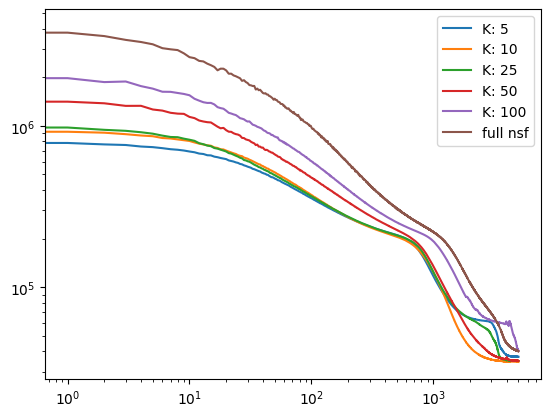

In [21]:
for k in k_numbers:
    plt.loglog(knn_models[k]['losses'], label='K: '+str(k))

plt.loglog(full_losses, label='full nsf')

plt.legend()

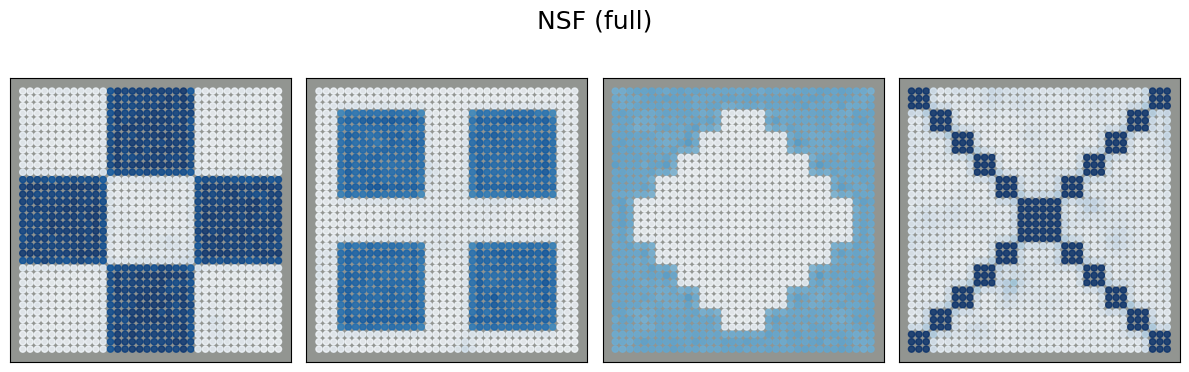

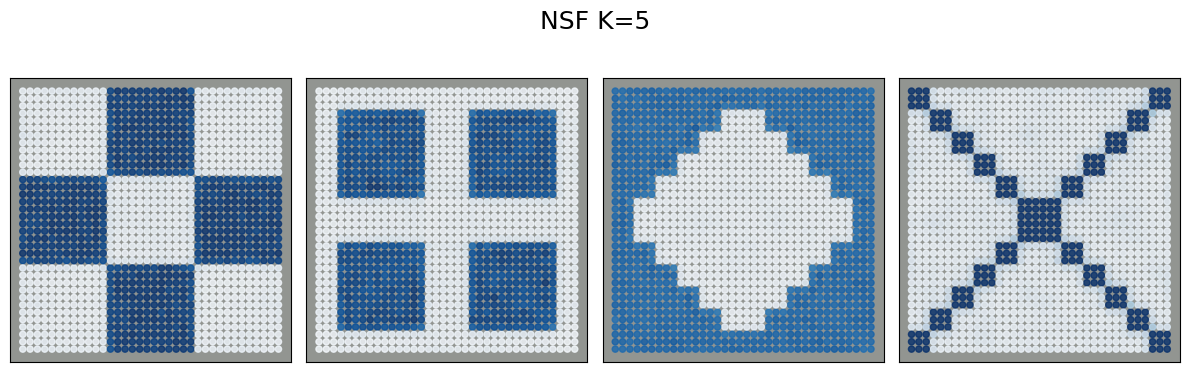

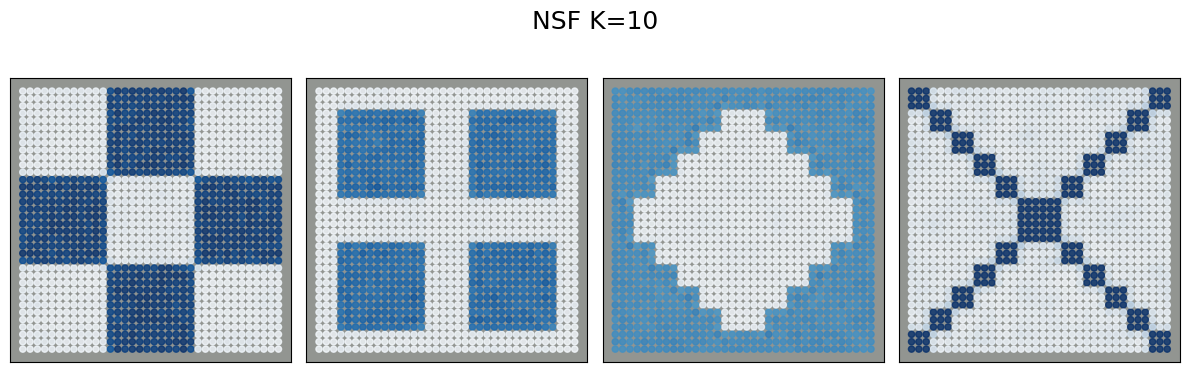

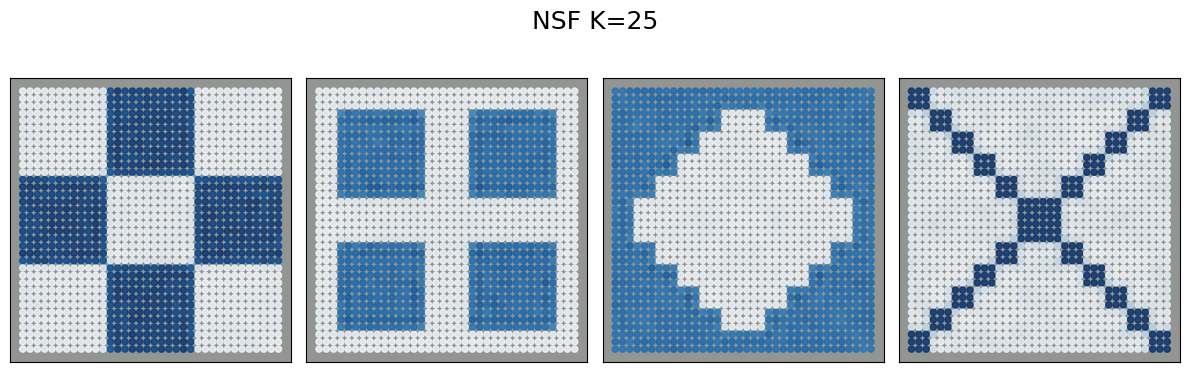

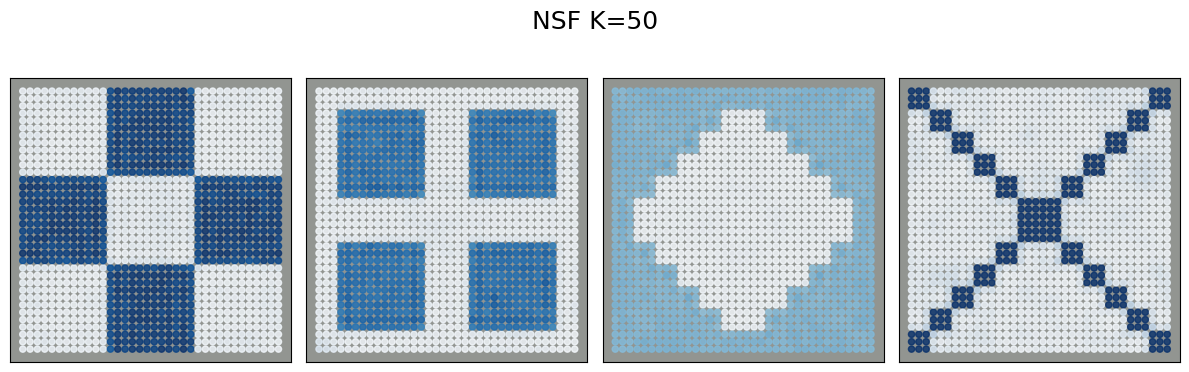

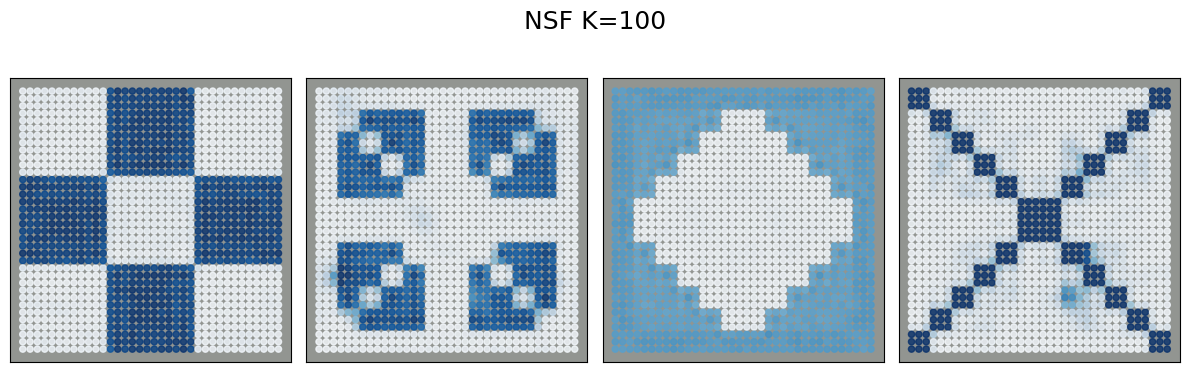

In [38]:
vmax = np.percentile(np.exp(nsf_mean), 95)
plot_factors(np.exp(nsf_mean), X, size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues', title="NSF (full)")
# plt.gcf().suptitle("NSF (full)", fontsize=18, y=1.03)


for k in k_numbers:
    current_mean =  knn_models[k]['mean']

    vmax = np.percentile(np.exp(current_mean), 95)
    
    plot_factors(np.exp(current_mean), X, size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues', title='NSF K='+str(k))

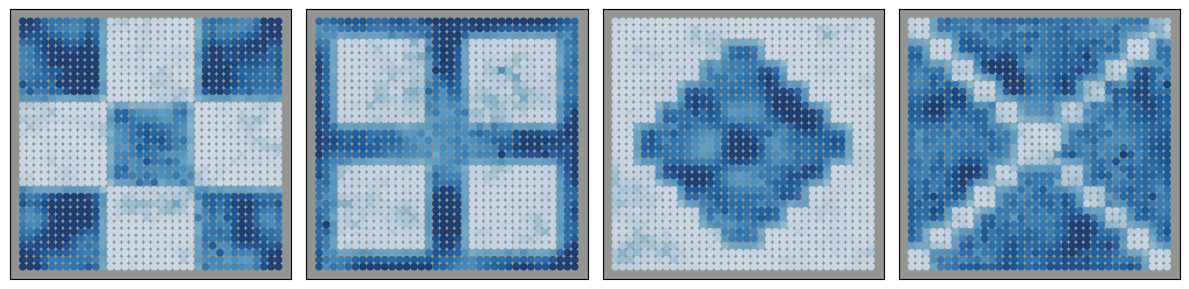

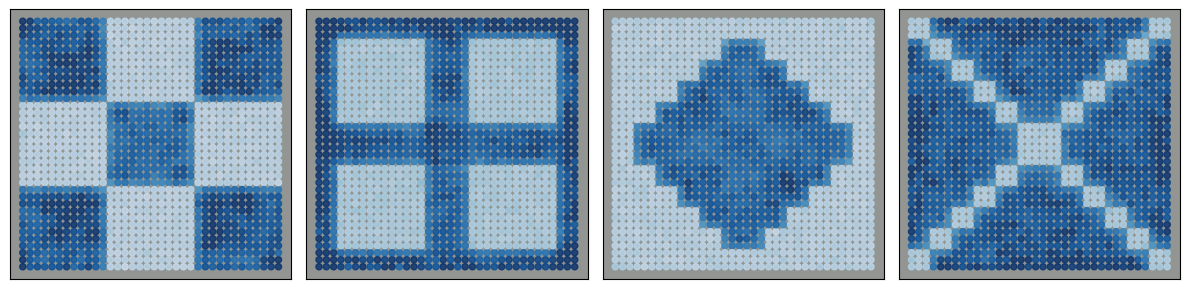

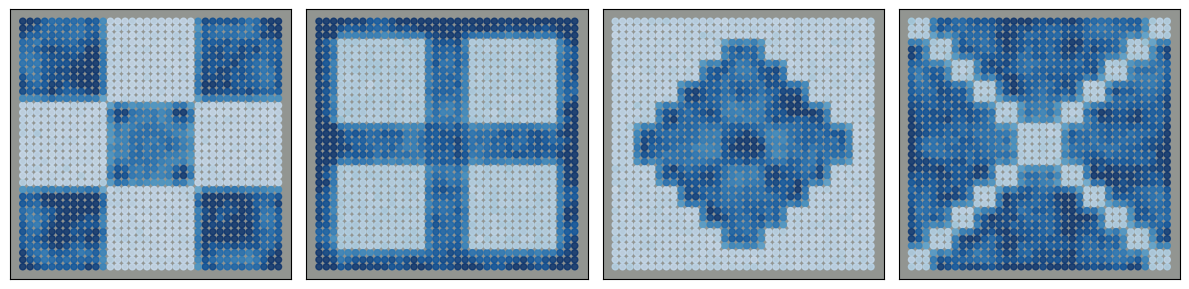

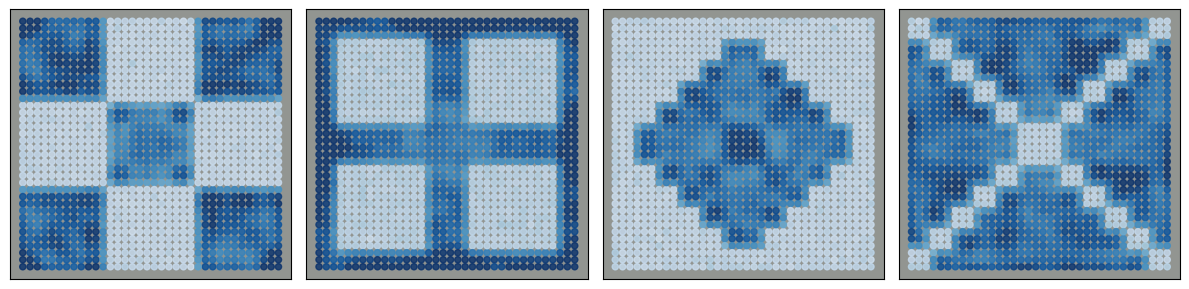

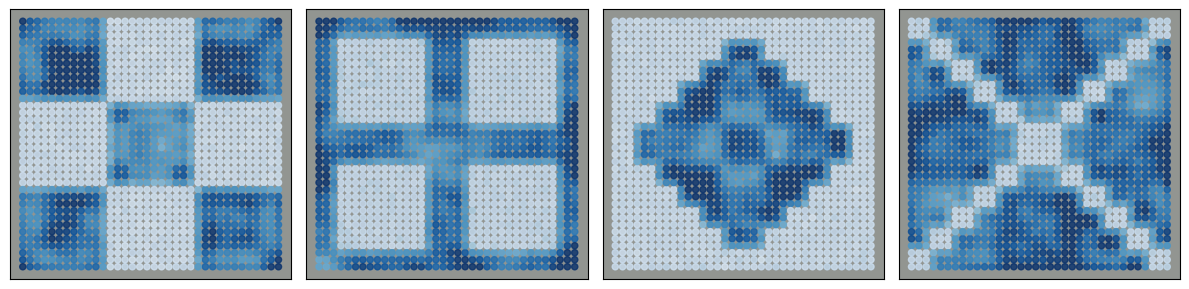

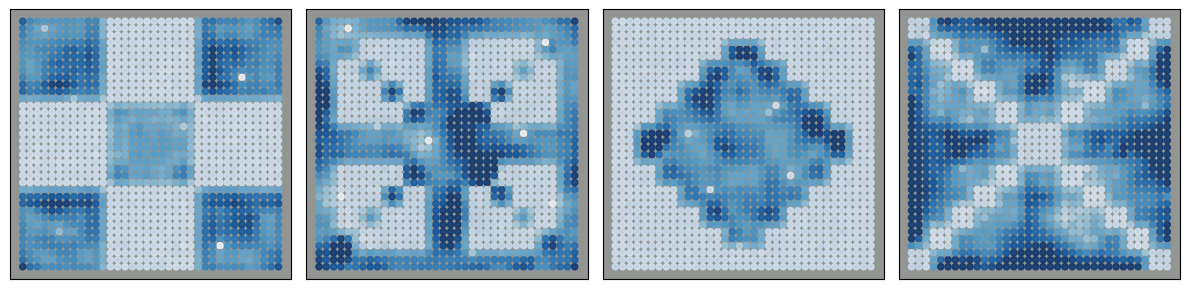

In [28]:
vmax = np.percentile(nsf_scale, 95)
plot_factors(nsf_scale, X, size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues')


for k in k_numbers:
    current_scale =  knn_models[k]['scale']

    vmax = np.percentile(current_scale, 95)
    
    plot_factors(current_scale, X, size=3, s=20.0, vmin=0, vmax=vmax, cmap='Blues')

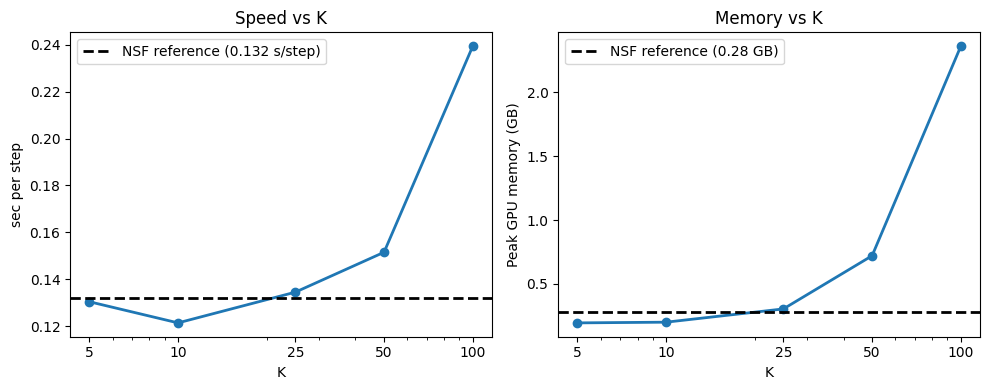

In [26]:
from matplotlib.ticker import ScalarFormatter

if summary_df is not None:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Extract reference: SVGP row
    ref = summary_df[summary_df["label"].str.contains("SVGP", case=False)].iloc[0]
    ref_sec = ref["sec_per_step"]
    ref_mem = ref["max_memory_allocated"] / (1024**3)

    # Mask to only VNNGP entries
    mask_knn = summary_df["K"].notna()

    # --- SPEED PLOT ---
    ax[0].plot(summary_df.loc[mask_knn, "K"], summary_df.loc[mask_knn, "sec_per_step"],
               marker="o", linewidth=2)
    ax[0].axhline(ref_sec, linestyle="--", color="black", linewidth=2,
                  label=f"NSF reference ({ref_sec:.3g} s/step)")
    ax[0].set_xscale("log")
    ax[0].set_xlabel("K")
    ax[0].set_ylabel("sec per step")
    ax[0].set_title("Speed vs K")
    ax[0].legend()

    # Proper integer log ticks
    ax[0].set_xticks(summary_df.loc[mask_knn, "K"])
    ax[0].get_xaxis().set_major_formatter(ScalarFormatter())
    ax[0].tick_params(axis='x', rotation=0)

    # --- MEMORY PLOT ---
    ax[1].plot(summary_df.loc[mask_knn, "K"],
               summary_df.loc[mask_knn, "max_memory_allocated"] / (1024**3),
               marker="o", linewidth=2)
    ax[1].axhline(ref_mem, linestyle="--", color="black", linewidth=2,
                  label=f"NSF reference ({ref_mem:.2f} GB)")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("K")
    ax[1].set_ylabel("Peak GPU memory (GB)")
    ax[1].set_title("Memory vs K")
    ax[1].legend()

    # Proper integer log ticks
    ax[1].set_xticks(summary_df.loc[mask_knn, "K"])
    ax[1].get_xaxis().set_major_formatter(ScalarFormatter())
    ax[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
